In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sys
import os
from tqdm import tqdm

In [5]:
sys.path.append(os.path.abspath(".."))

from lago_data_model.utils import plot_readings
from lago_data_model.data_utils import extract_pulses, extract_pulses_and_segments, process_dataframe_readings
from scipy.signal import butter, filtfilt, find_peaks

# Exploratory Data Analysis

In [6]:
data = pd.read_parquet("../data/20210518_142318.parquet")

In [7]:
data.head(5)

,TBP,readings
0,51491,"[198.0, 197.0, 197.0, 196.0, 197.0, 196.0, 197..."
1,168153,"[195.0, 194.0, 194.0, 194.0, 194.0, 194.0, 192..."
2,2613,"[197.0, 197.0, 198.0, 196.0, 196.0, 194.0, 194..."
3,111025,"[195.0, 194.0, 194.0, 192.0, 194.0, 190.0, 185..."
4,10736,"[197.0, 196.0, 197.0, 196.0, 197.0, 196.0, 193..."


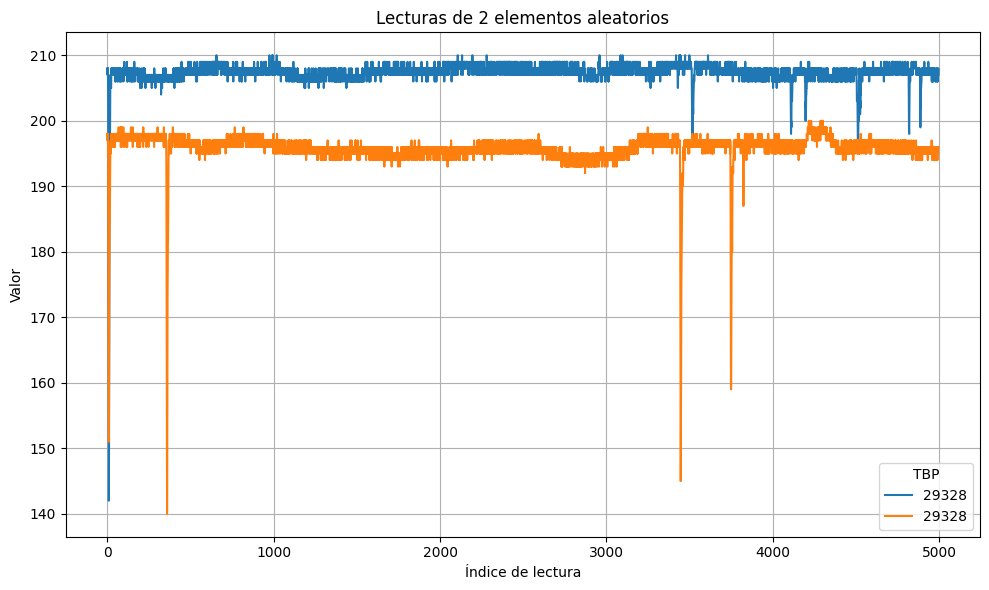

In [8]:
plot_readings(data[data['TBP']==29328], 2, legend=True)

## Detect Pulse

In [9]:
pulse_read = data[data['TBP']==29328]['readings'].iloc[0][:450]

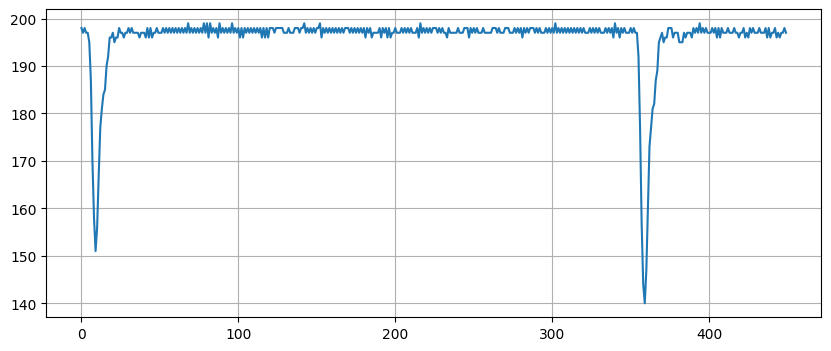

In [10]:
plt.figure(figsize=(10,4))
sns.lineplot(pulse_read)
plt.grid(True)

## Filter Butterworth low-pass 

- zedboard es con 500MHz
- red pitaya con 125MHz

In [12]:
# Sampling frequency (Hz)
fs = 600  

# Cut-off frequency for the low-pass filter (Hz)
fc = 20  

# Design a 4th-order Butterworth low-pass filter
b, a = butter(N=4, Wn=fc/(fs/2), btype='low')

# Apply the filter with zero-phase distortion
pulse_filtered = filtfilt(b, a, pulse_read)

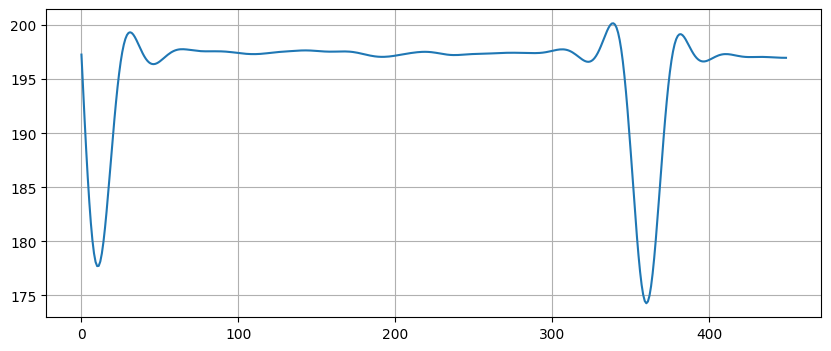

In [13]:
plt.figure(figsize=(10,4))
sns.lineplot(pulse_filtered)
plt.grid(True)

`nsigma * MAD` es un criterio estadístico para fijar el **umbral de detección** de pulsos:

- **MAD (Median Absolute Deviation)**:  
  Es una medida robusta de dispersión (similar a la desviación estándar, pero menos sensible a valores atípicos).  
  $ 
  MAD = \text{mediana}(|x_i - \text{mediana}(x)|)
  $

- **nsigma**:  
  Es un factor de escala. Por ejemplo, si `nsigma = 3`, se interpreta como "3 desviaciones típicas robustas".

- **nsigma * MAD**:  
  Indica cuán lejos del valor típico (mediana) debe estar una muestra para ser considerada parte de un pulso.  
  En el código, el umbral era:
  $
  \text{umbral} = \text{mediana}(x) - nsigma \cdot MAD
  $

## Características extraídas por `extract_pulses`

Sea la señal discreta `x[n]` y un pulso detectado en el intervalo `[n₀, n₁]` con mínimo en `n_min`.  
Definimos una línea de base local (*baseline*) como la mediana de muestras alrededor del pulso (antes y después, evitando solapamiento), denotada por `b`.

### Features

- **start_idx (`n₀`)**: índice donde comienza el pulso (primera muestra por debajo del umbral robusto).
- **min_idx (`n_min`)**: índice del valor mínimo dentro del pulso.
- **end_idx (`n₁`)**: índice donde termina el pulso (cuando la señal cruza de vuelta el umbral).
- **min_value = `x[n_min]`**: valor mínimo de la señal en el pulso.
- **baseline_local = `b`**: línea de base local estimada (mediana) alrededor del pulso.
- **depth = `b - x[n_min]`**: profundidad del pulso con respecto a la línea de base.
- **width_samples = `n₁ - n₀ + 1`**: ancho total del pulso en número de muestras.
- **area_under_pulse = Σ (b − x[n]) para n∈[n₀, n₁]**: área (o “carga”) del pulso por debajo de la línea de base.
- **fwhm_samples**: ancho a media altura (*Full Width at Half Maximum*), definido como el número de muestras para las que  
  `x[n] ≤ b − ½·depth` dentro de `[n₀, n₁]`.
- **rise_time = `n_min − n₀`**: tiempo (en muestras) desde el inicio del pulso hasta el mínimo.
- **recovery_time = `n₁ − n_min`**: tiempo (en muestras) desde el mínimo hasta el final del pulso.
- **snr_depth_over_mad = depth / MAD**: relación señal-ruido robusta,  
  donde `MAD = 1.4826 · mediana(|x[n] − mediana(x)|)`.

---

### Umbral de detección

El umbral de detección se fija con estadística robusta:

- Sea `x̃` la mediana global y `MAD` la desviación absoluta mediana ajustada.  
- El umbral primario se define como:



In [8]:
df_pulses = extract_pulses(
    pulse_read, 
    nsigma_threshold=3.0, crossback_nsigma=1.0, 
    min_len=3, baseline_win=25
)

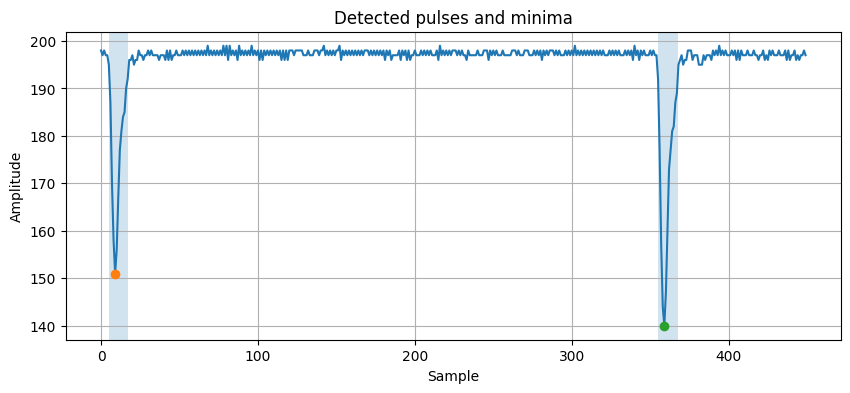

In [9]:
# Plot with detected regions and key points
plt.figure(figsize=(10,4))
plt.plot(pulse_read)
for _, r in df_pulses.iterrows():
    i0, i1 = int(r.start_idx), int(r.end_idx)
    kmin = int(r.min_idx)
    plt.axvspan(i0, i1, alpha=0.2)
    plt.plot(kmin, pulse_read[kmin], 'o')
plt.title("Detected pulses and minima")
plt.xlabel("Sample")
plt.ylabel("Amplitude")
plt.grid(True)
plt.show()

In [10]:
df_pulses

,start_idx,min_idx,end_idx,min_value,baseline_local,depth,width_samples,area_under_pulse,fwhm_samples,rise_time,recovery_time,snr_depth_over_mad
0,5,9,17,151.0,197.0,46.0,13,268.0,5,4,8,46.0
1,355,359,368,140.0,197.0,57.0,14,357.0,5,4,9,57.0


In [11]:
pulse_read = data.sample(1)['readings'].iloc[0]

In [12]:
df_pulses = extract_pulses(
    pulse_read, 
    nsigma_threshold=3.0, crossback_nsigma=1.0, 
    min_len=3, baseline_win=25
)

In [13]:
df_pulses

,start_idx,min_idx,end_idx,min_value,baseline_local,depth,width_samples,area_under_pulse,fwhm_samples,rise_time,recovery_time,snr_depth_over_mad
0,0,9,61,142.0,193.0,51.0,62,335.0,6,9,52,51.0
1,0,9,61,142.0,193.0,51.0,62,335.0,6,9,52,51.0
2,3423,3449,3635,192.0,194.0,2.0,213,202.0,210,26,186,2.0
3,3423,3449,3635,192.0,194.0,2.0,213,202.0,210,26,186,2.0
4,3423,3449,3635,192.0,194.0,2.0,213,202.0,210,26,186,2.0
5,3423,3449,3635,192.0,194.0,2.0,213,202.0,210,26,186,2.0
6,4994,4996,4997,0.0,198.0,198.0,4,406.0,2,2,1,198.0


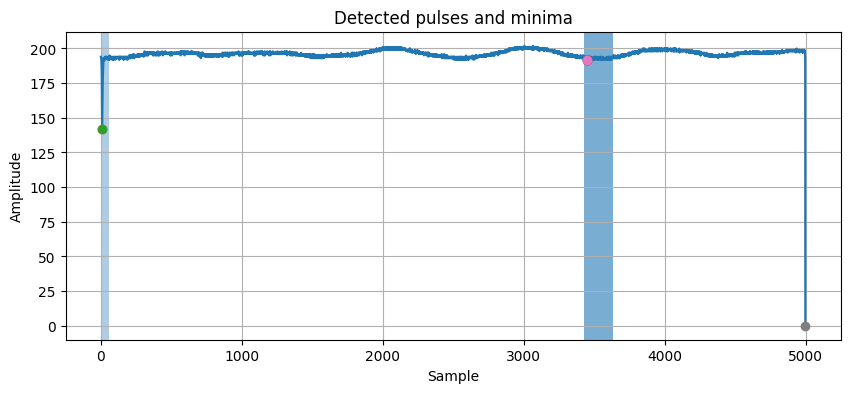

In [14]:
plt.figure(figsize=(10,4))
plt.plot(pulse_read)
for _, r in df_pulses.iterrows():
    i0, i1 = int(r.start_idx), int(r.end_idx)
    kmin = int(r.min_idx)
    plt.axvspan(i0, i1, alpha=0.2)
    plt.plot(kmin, pulse_read[kmin], 'o')
plt.title("Detected pulses and minima")
plt.xlabel("Sample")
plt.ylabel("Amplitude")
plt.grid(True)
plt.show()

# Extrar todos los pulsos

In [3]:
data = pd.concat([
    pd.read_parquet("../data/20210518_142318.parquet"),
    pd.read_parquet("../data/20210518_152318.parquet"),
    pd.read_parquet("../data/20210518_162318.parquet"),
    pd.read_parquet("../data/20210518_172318.parquet")
])

In [4]:
pulses_df, all_segments = process_dataframe_readings(data, "readings")

Pulsos por fila: 100%|██████████| 357625/357625 [08:06<00:00, 735.62it/s]


In [5]:
pulses_df.head()

,row_id,start_idx,min_idx,end_idx,min_value,baseline_local,depth,width_samples,area_under_pulse,fwhm_samples,rise_time,recovery_time,snr_depth_over_mad
0,0,8,11,19,113.0,195.0,82.0,12,528.0,6,3,8,13.666667
1,1,0,10,45,147.0,195.0,48.0,46,375.0,5,10,35,48.000000
2,1,0,10,45,147.0,195.0,48.0,46,375.0,5,10,35,48.000000
3,1,711,787,863,157.0,195.0,38.0,153,396.0,5,76,76,38.000000
4,1,711,787,863,157.0,195.0,38.0,153,396.0,5,76,76,38.000000


In [6]:
pulses_df.shape

(2366453, 13)

### Guardar los datos de los pulsos

In [7]:
pulses_df.to_csv("pulses.csv", index=False)

### Guardar los segmentos

In [15]:
import pickle

In [9]:
with open("all_segments.pkl", "wb") as f:
    pickle.dump(all_segments, f)

In [16]:
with open("all_segments.pkl", "rb") as f:
    segments = pickle.load(f)

In [ ]:
segments